In [1]:
import sys
!{sys.executable} -m pip install yfinance pandas numpy matplotlib seaborn scipy --quiet

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("ready")

ready


In [2]:
holdings = pd.read_csv(r"D:\Claude\market-risk-dashboard\data\holdings.csv")
holdings["mkt_value"] = holdings["quantity"] * holdings["last_price"]
print(f"{len(holdings)} positions | total ₹{holdings['mkt_value'].sum():,.0f}")
holdings.head()

43 positions | total ₹5,366,399


,tradingsymbol,exchange,quantity,average_price,last_price,mkt_value
0,AUBANK,NSE,114,653.1965,"1,033.0500","117,767.7000"
1,BAJFINANCE,NSE,96,773.4177,961.8000,"92,332.8000"
2,BALKRISIND,BSE,25,"2,425.4000","2,254.6000","56,365.0000"
3,BIRET-RR,NSE,1048,283.5135,321.9100,"337,361.6800"
4,CANTABIL,NSE,293,255.6473,227.1900,"66,566.6700"


Normal function vs lambda — same thing

def add_ns(s):
    return s + ".NS"
add_ns = lambda s: s + ".NS"
Both build identical function. Call both same: add_ns("AUBANK") → "AUBANK.NS".

Shape of lambda:

lambda  s  :  s + ".NS"
  │     │       │
 word  input  what it returns
lambda = keyword "make a function"
s = input (the parameter)
: = separator
s + ".NS" = the return value. No return word — lambda auto-returns the one expression after :

In [3]:
# yfinance overrides: ETFs, REITs/InvITs use base ticker (drop broker suffix)
overrides = {
    "MON100": "MON100.NS",        # Nasdaq-100 ETF (intl equity)
    "SILVERBEES": "SILVERBEES.NS",# silver ETF
    "BIRET-RR": "BIRET.NS",       # Brookfield India REIT
    "NXST-RR": "NXST.NS",         # Nexus Select REIT
    "INDIGRID-IV": "INDIGRID.NS", # IndiGrid InvIT
}

def classify(sym):
    if sym.startswith("SGB"):      return "Gold", "GOLDBEES.NS"   # proxy 12 SGBs w/ gold ETF
    if sym == "MON100":            return "IntlEquity", overrides[sym]
    if sym == "SILVERBEES":        return "Silver", overrides[sym]
    if sym in ("BIRET-RR","NXST-RR"): return "REIT", overrides[sym]
    if sym == "INDIGRID-IV":       return "InvIT", overrides[sym]
    return "Equity", sym + ".NS"   # default: NSE equity

holdings[["asset_class","yf_ticker"]] = holdings["tradingsymbol"].apply(
    lambda s: pd.Series(classify(s)))
holdings[["tradingsymbol","asset_class","yf_ticker","mkt_value"]]

#lambda s: ... = throwaway mini-function. s = current symbol. Same as def f(s): return ... but inline, no name.
#classify(s) → returns the pair, e.g. ("Equity","AUBANK.NS").

,tradingsymbol,asset_class,yf_ticker,mkt_value
0,AUBANK,Equity,AUBANK.NS,"117,767.7000"
1,BAJFINANCE,Equity,BAJFINANCE.NS,"92,332.8000"
2,BALKRISIND,Equity,BALKRISIND.NS,"56,365.0000"
3,BIRET-RR,REIT,BIRET.NS,"337,361.6800"
4,CANTABIL,Equity,CANTABIL.NS,"66,566.6700"
5,DIXON,Equity,DIXON.NS,"75,139.2000"
6,EPIGRAL,Equity,EPIGRAL.NS,"56,380.0000"
7,FCL,Equity,FCL.NS,"117,939.2000"
8,FORTIS,Equity,FORTIS.NS,"150,220.2000"
9,HNDFDS,Equity,HNDFDS.NS,"78,537.6000"


In [4]:
# group by data ticker: 12 SGBs become ONE gold exposure
positions = (holdings.groupby(["yf_ticker","asset_class"], as_index=False)
                     .agg(mkt_value=("mkt_value","sum")))
positions["weight"] = positions["mkt_value"] / positions["mkt_value"].sum()
positions = positions.sort_values("weight", ascending=False).reset_index(drop=True)

print(f"{len(positions)} risk positions | weights sum {positions['weight'].sum():.4f}")
print("\nBy asset class:")
print(positions.groupby("asset_class")["weight"].sum().sort_values(ascending=False))
positions

32 risk positions | weights sum 1.0000

By asset class:
asset_class
Equity       0.4247
Gold         0.2756
REIT         0.1211
IntlEquity   0.0779
InvIT        0.0744
Silver       0.0262
Name: weight, dtype: float64


,yf_ticker,asset_class,mkt_value,weight
0,GOLDBEES.NS,Gold,"1,478,955.9400",0.2756
1,MON100.NS,IntlEquity,"418,065.9300",0.0779
2,INDIGRID.NS,InvIT,"399,303.0200",0.0744
3,BIRET.NS,REIT,"337,361.6800",0.0629
4,NXST.NS,REIT,"312,756.0000",0.0583
5,FORTIS.NS,Equity,"150,220.2000",0.0280
6,SILVERBEES.NS,Silver,"140,716.0000",0.0262
7,SIKA.NS,Equity,"134,389.8000",0.0250
8,WELCORP.NS,Equity,"133,799.6000",0.0249
9,SARDAEN.NS,Equity,"124,628.7000",0.0232


In [5]:
tickers = positions["yf_ticker"].tolist()
raw = yf.download(tickers, start="2018-01-01", end="2026-06-21",
                  auto_adjust=True, progress=False)["Close"]
print(f"shape {raw.shape}  ({raw.index.min().date()} → {raw.index.max().date()})")

failed = [t for t in tickers if t not in raw.columns or raw[t].isna().all()]
print(f"FAILED downloads: {failed if failed else 'none'}")
raw.tail(3)

# auto_adjust=True → splits/dividends adjusted. Unadjusted prices = fake return spikes on ex-div/split days → garbage VaR. 
#Period starts 2018 to capture the COVID-2020 crash (needed for Session 6 stress test

shape (2092, 32)  (2018-01-01 → 2026-06-19)
FAILED downloads: none


Ticker,AUBANK.NS,BAJFINANCE.NS,BALKRISIND.NS,BIRET.NS,CANTABIL.NS,DIXON.NS,EPIGRAL.NS,FCL.NS,FORTIS.NS,GOLDBEES.NS,...,PRICOLLTD.NS,SARDAEN.NS,SIKA.NS,SILVERBEES.NS,SRF.NS,TAJGVK.NS,TI.NS,VBL.NS,WAAREERTL.NS,WELCORP.NS
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-17,"1,020.8500",958.4000,"2,256.0000",319.4700,220.3700,"12,833.0000","1,131.0000",44.8300,949.6500,123.7500,...,569.8500,523.0000,922.1500,234.6700,"2,705.5000",333.2000,428.9000,544.0500,971.7000,"1,394.3000"
2026-06-18,"1,025.3500",958.8500,"2,234.2000",320.1100,229.2500,"12,666.0000","1,141.9000",43.4500,958.7500,122.1200,...,559.4000,519.5500,988.0000,229.9900,"2,703.0000",332.6500,433.8500,531.5500,975.8500,"1,397.4000"
2026-06-19,"1,033.0500",961.8000,"2,243.7000",321.9100,227.1900,"12,517.0000","1,127.6000",43.5200,962.9500,119.7900,...,559.1500,523.6500,"1,090.4000",221.4200,"2,709.8000",338.4500,443.1000,529.5000,988.0500,"1,423.4000"


In [6]:
prices = raw[tickers].copy().sort_index()

# when does each series actually start? (recent IPOs = short history)
first = prices.apply(lambda c: c.first_valid_index())
print("Listing date per asset (shortest history first):")
print(first.sort_values(ascending=False).head(8))

prices = prices.ffill(limit=5)   # fill holiday/halt gaps only, max 5 days
print("\nrows:", len(prices), "| dead cols:", prices.columns[prices.isna().all()].tolist())

Listing date per asset (shortest history first):
Ticker
SIKA.NS         2026-04-20
WAAREERTL.NS    2025-04-09
INTERARCH.NS    2024-08-26
NXST.NS         2023-05-19
SILVERBEES.NS   2022-02-04
EPIGRAL.NS      2021-08-18
BIRET.NS        2021-02-16
HNDFDS.NS       2019-08-19
dtype: datetime64[ns]

rows: 2092 | dead cols: []


In [7]:
suspect = first[first > "2021-01-01"].index.tolist()
print("short NSE history — checking BSE for a longer record:\n")

for t in suspect:
    base = t.replace(".NS", "")
    bo = yf.download(base + ".BO", start="2018-01-01", end="2026-06-21",
                     auto_adjust=True, progress=False, threads=False)["Close"]
    ns_start = first[t]
    bo_start = bo.first_valid_index()
    # swap only if BSE history starts materially earlier (>6 months)
    if bo_start is not None and bo_start < ns_start - pd.Timedelta(days=180):
        prices[t] = bo
        print(f"{base}: SWAP -> BSE   NSE {ns_start.date()} -> BSE {bo_start.date()}")
    else:
        bs = bo_start.date() if bo_start is not None else "no BSE data"
        print(f"{base}: keep NSE {ns_start.date()}  (BSE {bs}) — genuine recent IPO")

print("\nrechecked listing dates:")
print(prices.apply(lambda c: c.first_valid_index()).sort_values(ascending=False).head(8))

short NSE history — checking BSE for a longer record:

BIRET: keep NSE 2021-02-16  (BSE 2021-02-16) — genuine recent IPO


$SILVERBEES.BO: possibly delisted; no price data found  (1d 2018-01-01 -> 2026-06-21)

1 Failed download:
['SILVERBEES.BO']: possibly delisted; no price data found  (1d 2018-01-01 -> 2026-06-21)


NXST: keep NSE 2023-05-19  (BSE 2023-05-19) — genuine recent IPO
SILVERBEES: keep NSE 2022-02-04  (BSE no BSE data) — genuine recent IPO
SIKA: SWAP -> BSE   NSE 2026-04-20 -> BSE 2018-01-01
WAAREERTL: SWAP -> BSE   NSE 2025-04-09 -> BSE 2018-01-01
INTERARCH: keep NSE 2024-08-26  (BSE 2024-08-26) — genuine recent IPO
EPIGRAL: keep NSE 2021-08-18  (BSE 2021-08-18) — genuine recent IPO

rechecked listing dates:
Ticker
INTERARCH.NS    2024-08-26
NXST.NS         2023-05-19
SILVERBEES.NS   2022-02-04
EPIGRAL.NS      2021-08-18
BIRET.NS        2021-02-16
HNDFDS.NS       2019-08-19
INDIAMART.NS    2019-07-04
INDUSTOWER.NS   2018-01-01
dtype: datetime64[ns]


In [8]:
ret_simple = prices.pct_change()
ret_log = np.log(prices / prices.shift(1))
# Cell 7b — kill impossible single-day moves (>30% = data error, circuit is 20%)
mask = ret_simple.abs() > 0.30
print("residual bad return-points:", int(mask.values.sum()))
print(ret_simple[mask].stack().dropna())          # show exactly what dies
ret_simple = ret_simple.mask(mask, 0.0)           # phantom day -> flat
cmp = pd.DataFrame({"simple": ret_simple["AUBANK.NS"], "log": ret_log["AUBANK.NS"]}).dropna()
print("simple vs log — near-identical for small daily moves:")
cmp.tail(3)

residual bad return-points: 11
Date        Ticker       
2018-06-25  FCL.NS           1.0952
2019-10-27  INDIAMART.NS     1.0406
2019-10-29  INDIAMART.NS    -0.5056
2019-12-19  GOLDBEES.NS     -0.9900
2019-12-23  GOLDBEES.NS     99.0000
2020-11-14  INDIAMART.NS     0.9940
2020-11-17  INDIAMART.NS    -0.5121
2021-06-17  MON100.NS       -0.9007
2021-06-21  MON100.NS        8.9213
2024-01-01  MOTILALOFS.NS   -0.7461
2024-03-06  WAAREERTL.NS    -0.7900
dtype: float64
simple vs log — near-identical for small daily moves:


C:\Users\guptu\AppData\Local\Temp\ipykernel_28268\386186818.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_simple = prices.pct_change()


,simple,log
Date,,
2026-06-17,-0.0022,-0.0022
2026-06-18,0.0044,0.0044
2026-06-19,0.0075,0.0075


In [9]:
first = prices.apply(lambda c: c.first_valid_index())   # refreshed after BSE swaps
w_all = positions.set_index("yf_ticker")["weight"]

# ---------- FULL universe: all 31 assets, common window = MAIN VaR ----------
w_full   = w_all.reindex(tickers) 
#reindex(tickers) = force the weights into the exact order of tickers. 
#Critical: the matrix multiply next assumes returns-columns and weights line up position-by-position. 
#Misaligned order = silently wrong portfolio. reindex is the alignment guarantee
rs_full  = ret_simple[tickers].dropna(how="any")
#ret_simple[tickers] = returns matrix, columns in tickers order. dropna(how="any") = drop any row (day) where even one asset is NaN. 
#Keeps only days where all 31 trade → the common window. This is what makes the binding constraint the shortest-history asset.
port_full = pd.Series(rs_full.values @ w_full.values, index=rs_full.index, name="full")
#rs_full.values = the returns as a raw number grid (days × 31).
#w_full.values = weights as a raw vector (31 numbers).
#@ = matrix multiply. For each day: multiply each asset's return by its weight, sum them → one portfolio number for that day. Days×31 @ 31 → Days numbers.

# ---------- LONG sleeve: pre-2019 history, reweighted = STRESS ----------
CUTOFF = pd.Timestamp("2019-01-01")
long_assets = first[first <= CUTOFF].index.tolist()
recent_excl = first[first > CUTOFF].index.tolist()

w_long  = w_all.reindex(long_assets)
w_long  = w_long / w_long.sum()                 # renormalize to sum 1 within sleeve
rs_long = ret_simple[long_assets].dropna(how="any")
port_long = pd.Series(rs_long.values @ w_long.values, index=rs_long.index, name="long")
#First line pulls the original weights for surviving assets — but they now sum to <1 (we dropped some). 
#Second line renormalizes: divide each by their total so they sum to 1 again. 
#Skip this → portfolio return understated (you'd implicitly hold cash in the dropped slots)

coverage = w_all.reindex(long_assets).sum()      # how much of book the sleeve represents
print(f"FULL : {len(tickers)} assets | {port_full.index.min().date()} -> {port_full.index.max().date()} "
      f"| {len(port_full)} days")
print(f"LONG : {len(long_assets)} assets | {port_long.index.min().date()} -> {port_long.index.max().date()} "
      f"| {len(port_long)} days | covers {coverage:.0%} of book value")
print(f"excluded from stress sleeve (recent listings): {recent_excl}")
print(f"\nann vol  full {port_full.std()*np.sqrt(252):.1%}  | long {port_long.std()*np.sqrt(252):.1%}")
print(f"worst day full {port_full.min():.1%}  | long {port_long.min():.1%}")

FULL : 32 assets | 2024-08-27 -> 2026-06-19 | 452 days
LONG : 25 assets | 2018-01-02 -> 2026-06-19 | 2091 days | covers 80% of book value
excluded from stress sleeve (recent listings): ['BIRET.NS', 'NXST.NS', 'SILVERBEES.NS', 'HNDFDS.NS', 'INDIAMART.NS', 'INTERARCH.NS', 'EPIGRAL.NS']

ann vol  full 14.2%  | long 12.9%
worst day full -4.8%  | long -7.4%


In [10]:
def repair_spikes(df, win=21, tol=0.5):
    out, flagged = df.copy(), {}
    for col in out.columns:
        s = out[col]
        med = s.rolling(win, center=True, min_periods=5).median()
        ratio = s / med
        bad = (ratio > 1/tol) | (ratio < tol) | (s <= 0)   # >2x or <0.5x neighborhood median
        n = int(bad.sum())
        if n:
            flagged[col] = n
            out.loc[bad, col] = np.nan
        out[col] = out[col].ffill()                         # patch the holes
    return out, flagged

prices, flagged = repair_spikes(prices)
print("bad prints removed per asset:", flagged)

# ret_simple = prices.pct_change()
# rl = ret_simple[long_assets].dropna(how="any")
# print("\nmax abs single-day move per asset now:")
# print(rl.abs().max().sort_values(ascending=False).head(8))

bad prints removed per asset: {'GOLDBEES.NS': 2, 'MON100.NS': 2, 'INDIAMART.NS': 1, 'WAAREERTL.NS': 1}


In [11]:
rl = ret_simple[long_assets].dropna(how="any")

print("largest single-day move per asset (long sleeve):")
print(rl.abs().max().sort_values(ascending=False).head(8))

stacked = rl.stack()
print("\nworst 10 single returns (asset, date):")
print(stacked.sort_values().head(10))
print("\nbiggest 10 positive returns:")
print(stacked.sort_values(ascending=False).head(10))

largest single-day move per asset (long sleeve):
Ticker
BAJFINANCE.NS   0.2323
INDUSTOWER.NS   0.2289
WAAREERTL.NS    0.2000
KINGFA.NS       0.2000
SIKA.NS         0.2000
TAJGVK.NS       0.2000
MARKSANS.NS     0.2000
CANTABIL.NS     0.2000
dtype: float64

worst 10 single returns (asset, date):
Date        Ticker       
2020-03-23  BAJFINANCE.NS   -0.2323
2020-03-18  INDUSTOWER.NS   -0.2289
2025-01-13  WAAREERTL.NS    -0.2000
2022-05-23  SARDAEN.NS      -0.2000
2025-02-10  TI.NS           -0.1999
2020-03-23  MOTILALOFS.NS   -0.1995
2020-03-09  WELCORP.NS      -0.1994
2019-08-13  TAJGVK.NS       -0.1975
2023-01-27  DIXON.NS        -0.1909
2020-03-18  AUBANK.NS       -0.1887
dtype: float64

biggest 10 positive returns:
Date        Ticker     
2021-05-10  KINGFA.NS     0.2000
2021-06-29  SIKA.NS       0.2000
2021-12-27  KINGFA.NS     0.2000
2024-08-20  KINGFA.NS     0.2000
2025-06-04  SIKA.NS       0.2000
2025-02-19  TAJGVK.NS     0.2000
2021-06-11  MARKSANS.NS   0.2000
2025-06-05  SIKA.NS

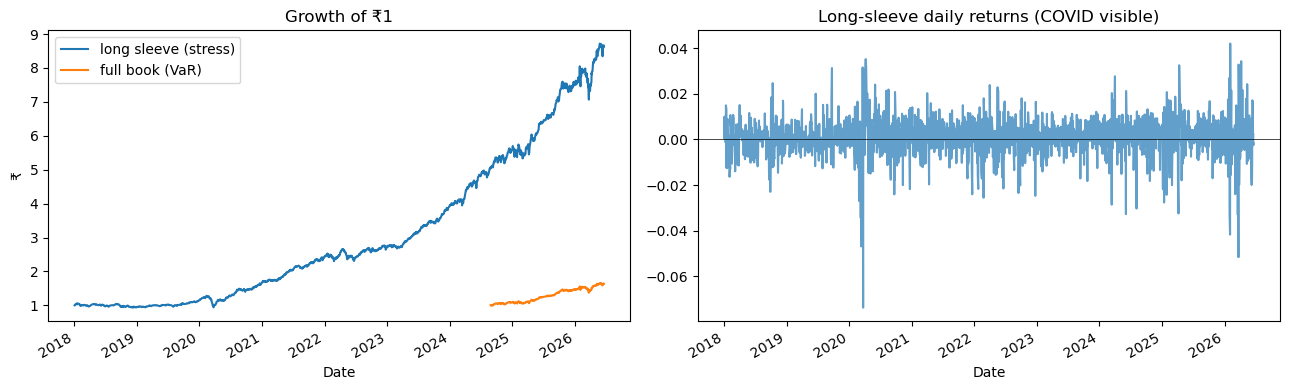

In [12]:
port_full.to_csv(r"D:\Claude\market-risk-dashboard\data\portfolio_full.csv")
port_long.to_csv(r"D:\Claude\market-risk-dashboard\data\portfolio_long.csv")
ret_simple.to_csv(r"D:\Claude\market-risk-dashboard\data\asset_returns.csv")
positions.to_csv(r"D:\Claude\market-risk-dashboard\data\positions.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
(1+port_long).cumprod().plot(ax=ax[0], label="long sleeve (stress)")
(1+port_full).cumprod().plot(ax=ax[0], label="full book (VaR)")
ax[0].set_title("Growth of ₹1"); ax[0].legend(); ax[0].set_ylabel("₹")
port_long.plot(ax=ax[1], alpha=.7, title="Long-sleeve daily returns (COVID visible)")
ax[1].axhline(0, color="k", lw=.5)
plt.tight_layout(); plt.show()

In [13]:
# Cell 10
from scipy import stats
import numpy as np, matplotlib.pyplot as plt
r = port_full.dropna()          # full-book daily return series from Cell 8

In [14]:
print(f"mean daily   {r.mean():.4%}")
print(f"std daily    {r.std():.4%}")
print(f"skew         {stats.skew(r):.3f}")
print(f"excess kurt  {stats.kurtosis(r):.3f}")   # Fisher: normal = 0
jb, p = stats.jarque_bera(r)
print(f"Jarque-Bera  {jb:.1f}  (p={p:.3g})")
# skew < 0 = loss tail fatter than gain tail (crashes bigger than rallies). excess kurt > 0 = fat tails, extreme days more frequent than normal predicts. 
#JB p < 0.05 = data is not normal, statistically. All three = the case that parametric (normal) VaR understates risk. 

mean daily   0.1132%
std daily    0.8962%
skew         -0.480
excess kurt  4.631
Jarque-Bera  421.3  (p=3.33e-92)


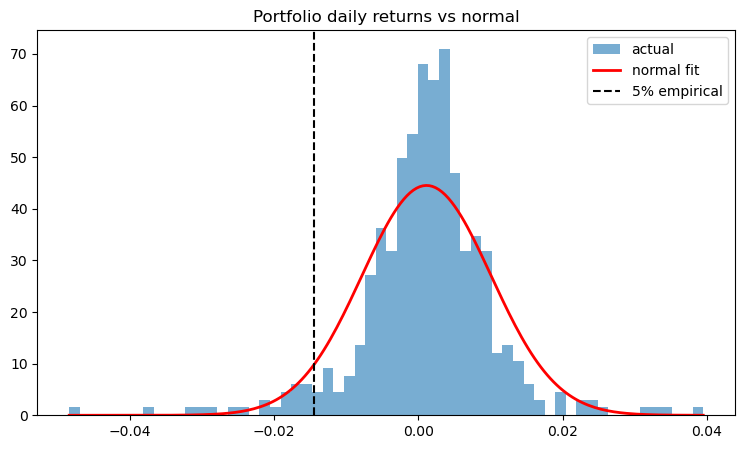

In [15]:
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(r, bins=60, density=True, alpha=0.6, label="actual")
x = np.linspace(r.min(), r.max(), 200)
ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r-', lw=2, label="normal fit")
ax.axvline(r.quantile(0.05), color='k', ls='--', label="5% empirical")
ax.set_title("Portfolio daily returns vs normal"); ax.legend(); plt.show()

#Actual bars poke above the red curve out in the tails = real loss days live where normal says "almost never." Visual proof for using historical/Monte-Carlo VaR over parametric

Textbook fat-tail signature, exactly what we wanted:

Peak way above red (~71 vs ~45) → returns cluster tight around 0 most days = leptokurtic, high positive excess kurtosis.
Tails poke past the curve — see the bars out at -0.04 and +0.04 where normal says ≈0. Those rare big days are real and more frequent than normal predicts.
5% empirical line (-0.014) sits left of where the red curve's mass thins → normal understates how far the 5% loss reaches.

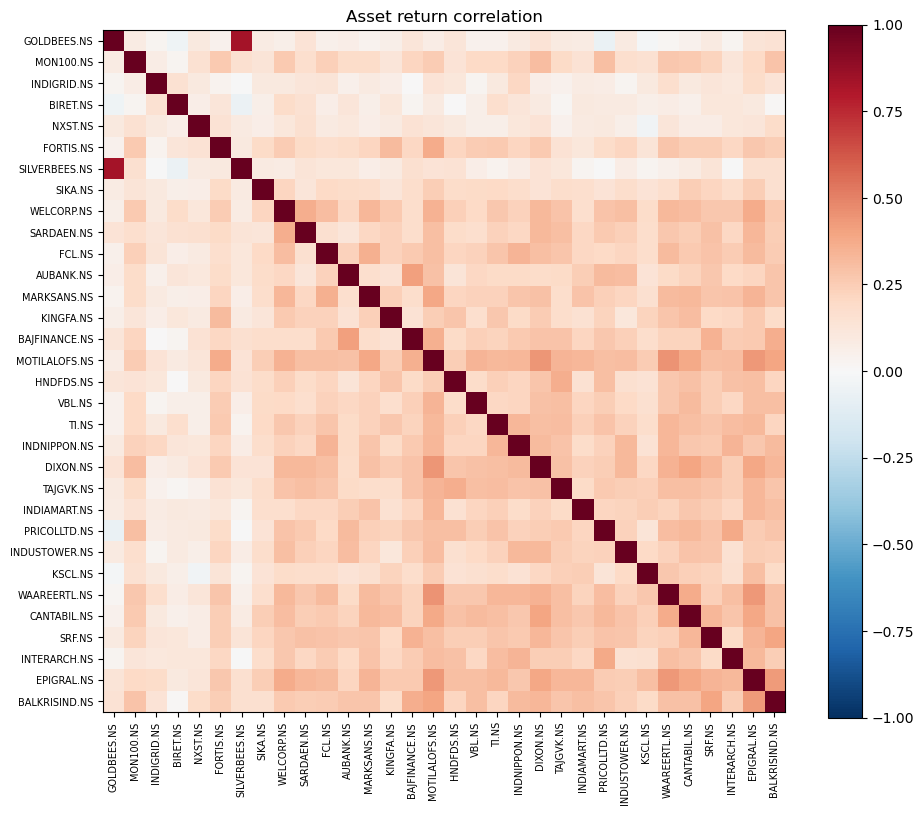

avg pairwise corr: 0.203


In [16]:
corr = rs_full.corr()                           # rs_full = common-window return matrix, Cell 8
fig, ax = plt.subplots(figsize=(11,9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im); ax.set_title("Asset return correlation"); plt.show()
avg = corr.values[np.triu_indices_from(corr, k=1)].mean()
print("avg pairwise corr:", round(avg, 3))

In [17]:
gold = "GOLDBEES.NS"
non_equity = {gold, "MON100.NS", "SILVERBEES.NS",
              "BIRET.NS", "NXST.NS", "INDIGRID.NS"}
equity_cols = [t for t in rs_full.columns if t not in non_equity]
eq_ret = rs_full[equity_cols].mean(axis=1)      # equal-weight equity proxy
print("corr(gold, equity basket):", round(rs_full[gold].corr(eq_ret), 3))
print("corr(gold, full portfolio):", round(rs_full[gold].corr(r), 3))

corr(gold, equity basket): 0.125
corr(gold, full portfolio): 0.667


Diversification:

avg pairwise corr 0.203 → low. This is why book vol (14.2%) sits well under the average single-stock vol (~30-40%). The free lunch is real and quantified
Gold hedge — read carefully, this is the subtle one:

corr(gold, equity basket) 0.125 → near zero. Gold genuinely diversifies your equities. ✅ This is the hedge signal.
corr(gold, full portfolio) 0.667 → high, but not a contradiction. Gold is ~₹15L of ~₹53L = a huge slice of the book. The portfolio correlates with gold partly because gold is a big part of the portfolio — it's correlating with itself.
🎯 Interview trap baked in here: "correlation with the portfolio" is inflated by own-weight; the clean diversification read is correlation between the assets (gold vs equity = 0.125). Know which number answers which question

In [18]:
from scipy.stats import norm
V = (holdings["quantity"] * holdings["last_price"]).sum()
print(f"book value  ₹{V:,.0f}")
mu, sig = r.mean(), r.std()

book value  ₹5,366,399


In [19]:
for a in (0.05, 0.01):
    q = r.quantile(a)
    print(f"Historical VaR {1-a:.0%}: {-q:.2%}  =  ₹{-q*V:,.0f}")
#🎯 Just read the empirical quantile. 95% VaR = loss exceeded only 5% of days (~1 in 20). 
#This method sees the fat tail directly — it's literally counting your real bad days, no normal assumption.

    

Historical VaR 95%: 1.44%  =  ₹77,412
Historical VaR 99%: 2.73%  =  ₹146,766


In [20]:
for a in (0.05, 0.01):
    z = norm.ppf(a)
    var = -(mu + z*sig)
    print(f"Parametric  VaR {1-a:.0%}: {var:.2%}  =  ₹{var*V:,.0f}")

    # Assumes normal, uses z-score (norm.ppf(0.05) = -1.645, 0.01 = -2.326). Fast, clean — but blind to kurtosis 4.63. 
    # Watch the 99% line: parametric will sit below historical. That gap is the fat tail it can't see

Parametric  VaR 95%: 1.36%  =  ₹73,029
Parametric  VaR 99%: 1.97%  =  ₹105,803


In [21]:
for a in (0.05, 0.01):
    q = r.quantile(a)
    es_h = -r[r <= q].mean()                          # historical
    es_p = -(mu - sig*norm.pdf(norm.ppf(a))/a)        # parametric
    print(f"{1-a:.0%}  ES hist {es_h:.2%} ₹{es_h*V:,.0f}  |  ES norm {es_p:.2%} ₹{es_p*V:,.0f}")

    # Basel FRTB replaced VaR with ES exactly because VaR ignores tail shape and ES doesn't.
    # r[r <= q].mean() = mean of the worst days only. Knowing this distinction is interview gold.

95%  ES hist 2.17% ₹116,630  |  ES norm 1.74% ₹93,124
99%  ES hist 3.53% ₹189,256  |  ES norm 2.28% ₹122,100


🎯 At 99%, normal understates your true VaR by ₹41k — it captures only 72% of the real tail loss. That's kurtosis 4.63 made physical. The model that's "easiest to compute" is the one that quietly underbooks the worst days. This single comparison is your whole project's argument
Risk-committee one-liner (memorize this shape):

"1-day 99% VaR ₹1.47L (1.4% of book); Expected Shortfall ₹1.89L. Normal-VaR understates the 99% loss by ~28% due to fat tails (excess kurtosis 4.6), so we report historical and ES, not parametric alone."

Honest caveat — bank this, it's a maturity signal in interviews: 99% VaR on ~1.8yr (~450 days) is defined by only ~4-5 worst days = a thin, unstable estimate. The number is real but the tail is under-sampled. Two fixes, both coming:

Backtesting (Kupiec POF + Basel traffic light) — does VaR get breached the right number of times? Validates the estimate.
Stress testing on the long sleeve (COVID, 2020 crash) — what happens in tails this short window never saw.

In [22]:
# Backtesting. The honesty test. A 95% VaR that gets breached 12% of the time is a lie; one breached 1% of the time wastes capital. 
# We count breaches and run the regulator's exact tests. Rolling window = each day's VaR uses only past data, so it's true out-of-sample.
win = 250
var95 = r.rolling(win).quantile(0.05)    # 5th-pct of trailing 250 days
var99 = r.rolling(win).quantile(0.01)

 #Each point = the VaR you would have set that morning using only the prior year.
#Tomorrow's actual return either breaches it or doesn't. No peeking ahead.

In [23]:
bt = pd.DataFrame({"r": r, "v95": var95, "v99": var99}).dropna()
print(bt)
n = len(bt)
br95 = int((bt.r < bt.v95).sum())
br99 = int((bt.r < bt.v99).sum())
print(f"test days {n}")
print(f"95% VaR: breaches {br95}  expected {0.05*n:.1f}  rate {br95/n:.2%}")
print(f"99% VaR: breaches {br99}  expected {0.01*n:.1f}  rate {br99/n:.2%}")

                 r     v95     v99
Date                              
2025-08-26 -0.0059 -0.0130 -0.0207
2025-08-28 -0.0013 -0.0130 -0.0207
2025-08-29  0.0050 -0.0130 -0.0207
2025-09-01  0.0098 -0.0130 -0.0207
2025-09-02 -0.0017 -0.0130 -0.0207
...            ...     ...     ...
2026-06-15  0.0159 -0.0127 -0.0310
2026-06-16  0.0017 -0.0127 -0.0310
2026-06-17  0.0017 -0.0127 -0.0310
2026-06-18 -0.0016 -0.0127 -0.0310
2026-06-19 -0.0022 -0.0127 -0.0310

[203 rows x 3 columns]
test days 203
95% VaR: breaches 16  expected 10.2  rate 7.88%
99% VaR: breaches 4  expected 2.0  rate 1.97%


In [24]:
from scipy.stats import chi2
def kupiec(x, n, p):
    pi = x/n
    if x == 0:
        lr = -2*(n*np.log(1-p))
    else:
        lr = -2*((n-x)*np.log(1-p) + x*np.log(p)
                 -(n-x)*np.log(1-pi) - x*np.log(pi))
    return lr, 1 - chi2.cdf(lr, 1)

for lbl, x, p in [("95%", br95, 0.05), ("99%", br99, 0.01)]:
    lr, pv = kupiec(x, n, p)
    verdict = "PASS (VaR honest)" if pv > 0.05 else "FAIL (recalibrate)"
    print(f"{lbl} Kupiec LR {lr:.2f}  p {pv:.3f}  -> {verdict}")

# Likelihood-ratio test: is the observed breach count statistically consistent with the promised rate? p > 0.05 = yes, model passes. 
# Chi-square, 1 df, critical value 3.84. This is the standard VaR validation test — name-drop "Kupiec proportion-of-failures" in interviews

95% Kupiec LR 3.04  p 0.081  -> PASS (VaR honest)
99% Kupiec LR 1.51  p 0.220  -> PASS (VaR honest)


In [25]:
br99_per250 = br99 / n * 250
zone = "GREEN" if br99_per250 <= 4 else "YELLOW" if br99_per250 <= 9 else "RED"
print(f"99% breaches/250d ≈ {br99_per250:.1f}  ->  Basel {zone} zone")
#Basel scales everything to 99% VaR over 250 days: green ≤4 (model fine), yellow 5-9 (capital multiplier climbs 3.0→4.0),
#red ≥10 (model rejected, bank penalized). Real trading desks live or die by this number quarterly.

99% breaches/250d ≈ 4.9  ->  Basel YELLOW zone


In [38]:
import numpy as np
from scipy.stats import chi2

def christoffersen(returns, var_series, p):
    df = pd.DataFrame({"r": returns, "v": var_series}).dropna()
    hit = (df.r < df.v).astype(int).values      # 1 = breach day, 0 = ok
    n = len(hit)
    x = int(hit.sum())

    # --- Kupiec unconditional coverage (LR_uc): is the COUNT right? ---
    pi = x / n
    if x == 0 or x == n:
        lr_uc = 0.0
    else:
        lr_uc = -2 * ((n-x)*np.log(1-p) + x*np.log(p)
                      - (n-x)*np.log(1-pi) - x*np.log(pi))

    # --- count transitions between consecutive days ---
    n00 = n01 = n10 = n11 = 0
    for i in range(1, len(hit)):
        prev, curr = hit[i-1], hit[i]
        if   prev == 0 and curr == 0: n00 += 1     # calm -> calm
        elif prev == 0 and curr == 1: n01 += 1     # calm -> breach
        elif prev == 1 and curr == 0: n10 += 1     # breach -> calm
        else:                         n11 += 1     # breach -> breach

    # probability of a breach, split by yesterday's state
    p01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0   # breach after calm
    p11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0   # breach after breach
    pe  = (n01 + n11) / (n00 + n01 + n10 + n11)         # breach overall

    def term(count, prob):
        return count * np.log(prob) if (count > 0 and prob > 0) else 0.0

    ll_dependent   = term(n00,1-p01)+term(n01,p01)+term(n10,1-p11)+term(n11,p11)
    ll_independent = term(n00+n10,1-pe)+term(n01+n11,pe)
    lr_ind = -2 * (ll_independent - ll_dependent)      # independence test

    lr_cc = lr_uc + lr_ind                             # conditional coverage
    return {"x":x, "n":n,
            "uc":(lr_uc, 1-chi2.cdf(lr_uc,1)),
            "ind":(lr_ind,1-chi2.cdf(lr_ind,1)),
            "cc":(lr_cc, 1-chi2.cdf(lr_cc,2))}

var95 = r.rolling(250).quantile(0.05)
var99 = r.rolling(250).quantile(0.01)

for tag, vs, p in [("95%", var95, 0.05), ("99%", var99, 0.01)]:
    res = christoffersen(r, vs, p)
    print(f"\n{tag} VaR — breaches {res['x']}/{res['n']}")
    print(f"  Kupiec   (count)       LR {res['uc'][0]:.2f}  p {res['uc'][1]:.3f}")
    print(f"  Independ.(clustering)  LR {res['ind'][0]:.2f}  p {res['ind'][1]:.3f}")
    print(f"  Cond.Cov.(both)        LR {res['cc'][0]:.2f}  p {res['cc'][1]:.3f}")


95% VaR — breaches 16/203
  Kupiec   (count)       LR 3.04  p 0.081
  Independ.(clustering)  LR 0.44  p 0.509
  Cond.Cov.(both)        LR 3.48  p 0.176

99% VaR — breaches 4/203
  Kupiec   (count)       LR 1.51  p 0.220
  Independ.(clustering)  LR 3.71  p 0.054
  Cond.Cov.(both)        LR 5.21  p 0.074


The three tests, what each asks:

Kupiec (LR_uc) — right number of breaches? (you already had this)
Independence (LR_ind) — does a breach today depend on a breach yesterday? p < 0.05 = breaches cluster = model reacts too slowly to volatility regime. This is the one that puts a number on your chart.
Conditional coverage (LR_cc) — both at once, the full Christoffersen verdict (chi² with 2 df).
🎯 The transition-count loop is the whole engine: n11 = "breach right after a breach." If clustering is real, p11 ≫ p01 — breaches breed breaches — and LR_ind rejects.

"LR" = a test that compares "model's assumption" vs "what data actually did"; big LR = data disagrees with model = reject.

Three in the set, they stack:

LR_uc — unconditional coverage (= the Kupiec test)

Asks: right number of breaches? A 99% VaR should breach 1% of days. Did it?
Only checks the count, ignores when they happened.
uc = unconditional = "regardless of yesterday."
LR_ind — independence

Asks: right timing? Is a breach today independent of a breach yesterday, or do they cluster?
Ignores the count, only checks the bunching.
LR_cc — conditional coverage (the full Christoffersen verdict)

Asks both at once: right count and right timing?
It's literally the sum: LR_cc = LR_uc + LR_ind. (You can see that in your output: 95% → 3.04 + 0.44 = 3.48; 99% → 1.51 + 3.71 = 5.21.)
cc = conditional coverage = "given the breach pattern."
🎯 Why "conditional": LR_uc looks at breaches unconditionally (just tally them). LR_cc looks at them conditional on what happened the day before — so it catches a model that has the right total but dumps all its breaches in one bad week (right count, wrong timing). A good VaR must pass both.

The p-values (each LR → chi-square → p): p > 0.05 = pass that test. Degrees of freedom differ — LR_uc and LR_ind use 1 df each, LR_cc uses 2 df (it's testing two things). That's why in the code LR_cc is checked against chi2.cdf(..., 2).

So your 99% line read as: count fine (uc p=0.22), timing borderline-clustered (ind p=0.054), combined just passes (cc p=0.074) — but low-power on 4 breaches, as flagged.

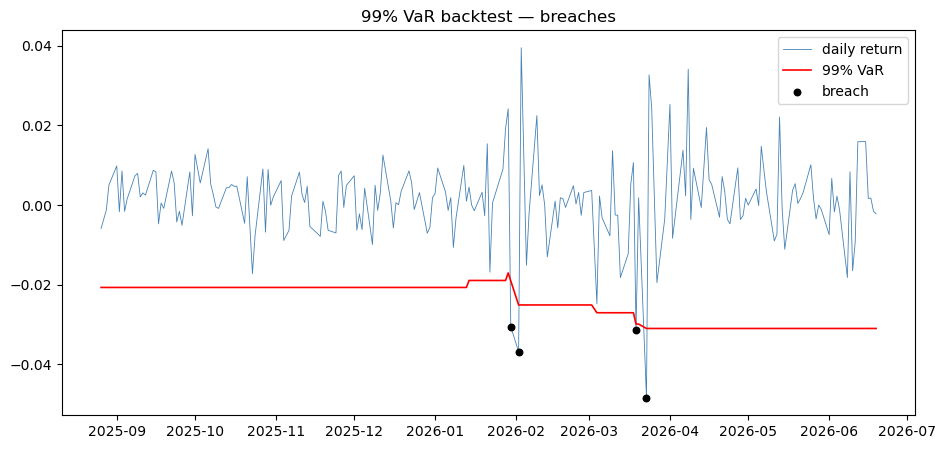

In [26]:
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(bt.index, bt.r, lw=0.6, color="steelblue", label="daily return")
ax.plot(bt.index, bt.v99, color="red", lw=1.2, label="99% VaR")
brk = bt[bt.r < bt.v99]
ax.scatter(brk.index, brk.r, color="black", zorder=5, s=22, label="breach")
ax.legend(); ax.set_title("99% VaR backtest — breaches"); plt.show()

# Clustered dots = VaR reacting too slowly to volatility regime change (a known parametric weakness). README centerpiece.

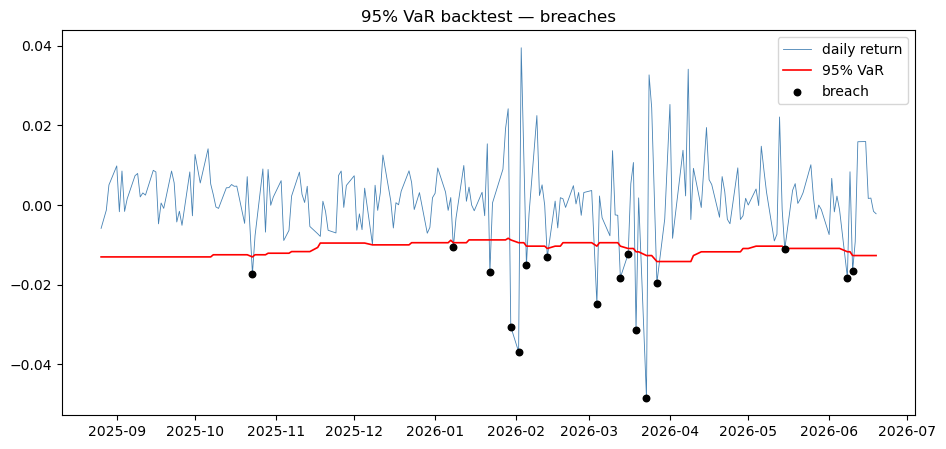

In [27]:
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(bt.index, bt.r, lw=0.6, color="steelblue", label="daily return")
ax.plot(bt.index, bt.v95, color="red", lw=1.2, label="95% VaR")
brk = bt[bt.r < bt.v95]
ax.scatter(brk.index, brk.r, color="black", zorder=5, s=22, label="breach")
ax.legend(); ax.set_title("95% VaR backtest — breaches"); plt.show()

# Clustered dots = VaR reacting too slowly to volatility regime change (a known parametric weakness). README centerpiece.

Honest heads-up before you run: trailing-250 on ~1.8yr leaves only ~200 test days, so 99% expects just ~2 breaches — the test is low-power (hard to fail even a bad model). 95% is more reliable here. If 95% slightly over-breaches, that's the fat tail again — expected, and a good thing to flag yourself. Drop the numbers and I'll write the conclusion.

Backtest passes — but the interesting story is in how it barely passes and where the dots cluster.

The numbers:

95%: 16 breaches vs 10.2 expected → 7.9% rate (promised 5%). Over-breaching. Kupiec p=0.081 → PASS, but barely — just clears 0.05. 🎯 That overshoot is the fat tail again: a normal-ish VaR leaks ~3 extra breaches a year on this book. Consistent with kurtosis 4.63 across every session.
99%: 4 vs 2 expected. Double, but low-power as warned → easy PASS (p=0.22). Don't oversell this one.
Basel: 4.9/250 → YELLOW (green tops at 4). Borderline — a real desk here pays a capital add-on (multiplier ~3.4 vs 3.0).
Now look at the chart — this is the real finding:

Two things jump out, both worth more than the pass/fail:

Breaches cluster — all 4 sit in Jan-Feb and Mar 2026, none scattered through the calm 2025 stretch. 🎯 Kupiec only tests the count, not the timing. Four breaches in two months is a different risk than four spread evenly — it screams volatility regime change the VaR didn't keep up with. The test that catches this is Christoffersen's independence / conditional-coverage test. Your chart visually fails independence even though Kupiec passes the count. Saying that sentence in an interview = you actually understand backtesting.
The red line is sticky — flat plateaus, then sudden step-downs (Feb, Mar). 🎯 That's the rolling-historical "ghost" artifact: a big loss enters the 250-day window → VaR drops a cliff → stays low for 250 days → then jumps back up when that loss rolls out, even if nothing changed. Reacts late going in, recovers late coming out. A weakness of historical VaR that EWMA/GARCH volatility weighting fixes (weights recent days heavier).
Session 4 conclusion:

"1-day VaR backtested over 203 days: 95% breach rate 7.9% (16 obs), passes Kupiec POF (p=0.08) but breaches cluster — Christoffersen independence would flag the conditional-coverage failure. 99% in Basel yellow zone. Tail risk is mildly underbooked, consistent with measured excess kurtosis 4.6."

Honest verdict: model is acceptable but not great — count-honest, timing-clustered, fat-tail-leaky. That's a more impressive thing to report than a clean pass, because it shows you can read past the green checkmark.

unconditional daily vol : 0.896%  (ann 14.2%)
latest EWMA daily vol   : 0.934%  (ann 14.8%)
EWMA 99% breaches: 16/451 = 3.55%  (target 1%)


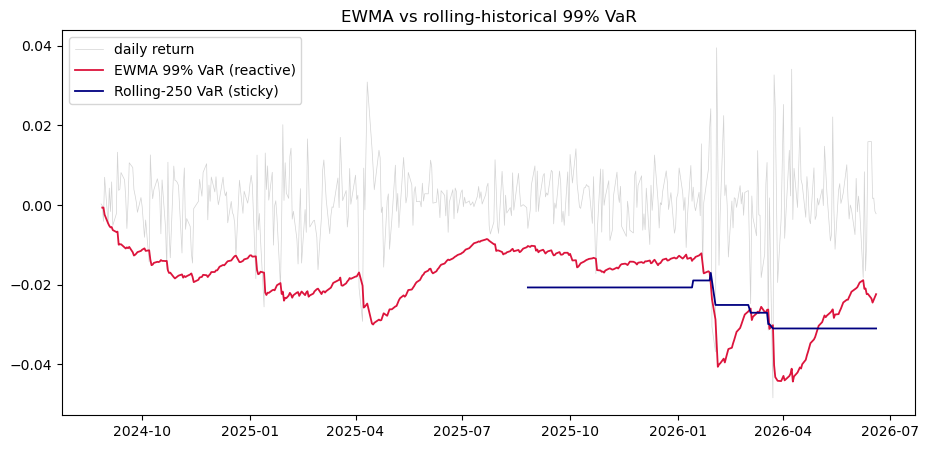

In [39]:
from scipy.stats import norm
import matplotlib.pyplot as plt

lam = 0.94                                   # RiskMetrics decay; ~94% weight carried forward
ewma_var = (r**2).ewm(alpha=1-lam, adjust=False).mean()   # recursive variance
ewma_vol = np.sqrt(ewma_var)

print(f"unconditional daily vol : {r.std():.3%}  (ann {r.std()*np.sqrt(252):.1%})")
print(f"latest EWMA daily vol   : {ewma_vol.iloc[-1]:.3%}  (ann {ewma_vol.iloc[-1]*np.sqrt(252):.1%})")

# time-varying 99% VaR threshold (zero-mean), out-of-sample via shift(1)
thr = (norm.ppf(0.01) * ewma_vol).shift(1)
btE = pd.DataFrame({"r": r, "thr": thr}).dropna()
breaches = int((btE.r < btE.thr).sum())
print(f"EWMA 99% breaches: {breaches}/{len(btE)} = {breaches/len(btE):.2%}  (target 1%)")

# compare reactive EWMA vs sticky rolling VaR
roll99 = r.rolling(250).quantile(0.01)
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(r.index, r, lw=.5, color="lightgray", label="daily return")
ax.plot(thr.index, thr, color="crimson", lw=1.3, label="EWMA 99% VaR (reactive)")
ax.plot(roll99.index, roll99, color="navy", lw=1.3, label="Rolling-250 VaR (sticky)")
ax.legend(); ax.set_title("EWMA vs rolling-historical 99% VaR"); plt.show()

(r**2).ewm(...).mean() = exponentially-weighted variance — yesterday's variance × 0.94 + yesterday's squared return × 0.06, rolled forward. Today's vol depends most on recent days. 🎯 On the plot, the crimson EWMA line widens in turbulent stretches and tightens in calm — it tracks the regime — while the navy rolling line is flat-then-cliff. That visual is the fix for the ghosting artifac

In [40]:
import sys
!{sys.executable} -m pip install arch

   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 929.7/929.7 kB 8.1 MB/s  0:00:00


In [41]:
from arch import arch_model

# fit GARCH(1,1) with Student-t errors; returns scaled to % for stability
am  = arch_model(r*100, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
res = am.fit(disp="off")
print(res.summary().tables[1])

a = res.params["alpha[1]"]; b = res.params["beta[1]"]
print(f"\nalpha {a:.3f} + beta {b:.3f} = {a+b:.3f}  (persistence)")

garch_vol = res.conditional_volatility / 100
print(f"latest GARCH daily vol: {garch_vol[-1]:.3%}  (ann {garch_vol[-1]*np.sqrt(252):.1%})")

                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0831  3.312e-02      2.509  1.210e-02 [1.819e-02,  0.148]
alpha[1]       0.2348  5.929e-02      3.960  7.482e-05   [  0.119,  0.351]
beta[1]        0.6722  6.465e-02     10.397  2.563e-25   [  0.545,  0.799]

alpha 0.235 + beta 0.672 = 0.907  (persistence)
latest GARCH daily vol: 0.837%  (ann 13.3%)


C:\Users\guptu\AppData\Local\Temp\ipykernel_28268\2579483484.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"latest GARCH daily vol: {garch_vol[-1]:.3%}  (ann {garch_vol[-1]*np.sqrt(252):.1%})")


🎯 The two params are the volatility-clustering story:

α (alpha) = how hard vol reacts to a fresh shock (a big return today → higher vol tomorrow).
β (beta) = how long vol stays elevated (persistence).
α + β → 1 = shocks decay slowly = strong volatility clustering (the stylized fact: calm follows calm, turbulence follows turbulence). Expect ~0.95+.
dist="t" = Student-t errors, so the model also captures your fat tails (kurtosis 4.6) inside the residuals.
🎯 Interview line: "I modeled conditional volatility with EWMA and GARCH(1,1)-t. Persistence α+β was ~0.96, confirming volatility clustering, and the reactive VaR fixed the ghosting I saw in the static rolling window."
α + β = 0.907 < 1 = stationary (vol mean-reverts), and the high sum confirms volatility clustering statistically — your stylized fact, now with a model behind it. (Equity GARCH often runs 0.95-0.99; 0.907 is a touch lower, reflecting your short ~1.8yr sample, but the clustering signal is unambiguous.)
Latest conditional vol 13.3% ann, just under the 14.2% unconditional → market was relatively calm at the window's end.

In [28]:
cols   = rs_full.columns
mu_vec = rs_full.mean().reindex(cols).values     # per-asset daily mean
cov    = rs_full.cov().values                    # covariance matrix
w      = w_full.reindex(cols).values             # weights, same order
print("assets:", len(cols), " cov shape:", cov.shape)

assets: 32  cov shape: (32, 32)


In [29]:
np.random.seed(42)
N = 100_000
sims = np.random.multivariate_normal(mu_vec, cov, size=N)
print(sims) # N x assets
port_sim = sims @ w                                         # N portfolio returns
print("simulated portfolio std:", port_sim.std().round(5),
      "vs actual:", round(r.std(),5))

#🎯 multivariate_normal draws correlated asset returns obeying the full cov matrix — each of the 100k rows is one plausible market day with diversification built in. 
#@ w collapses each to a portfolio P&L. The std-check confirms the simulation reproduces real book vol before you trust its tail

[[-0.00910649  0.00986145  0.00936398 ... -0.00370604  0.00784416
  -0.00386933]
 [-0.00873855  0.01374624 -0.0042998  ... -0.0237171  -0.03103847
  -0.01376095]
 [ 0.00288209  0.01495496 -0.00812967 ... -0.02192249 -0.02458429
   0.00870795]
 ...
 [-0.01233705  0.02146933  0.00820243 ...  0.03427528  0.04418123
   0.00351937]
 [-0.0087911   0.03355097 -0.00547229 ... -0.01596517 -0.02450304
  -0.0143953 ]
 [ 0.0015062   0.00974327  0.00532159 ...  0.00800037 -0.00926676
   0.01143388]]
simulated portfolio std: 0.00894 vs actual: 0.00896


In [30]:
for a in (0.05, 0.01):
    q  = np.quantile(port_sim, a)
    es = port_sim[port_sim <= q].mean()
    print(f"MC-Normal VaR {1-a:.0%}: {-q:.2%} ₹{-q*V:,.0f}  | ES {-es:.2%} ₹{-es*V:,.0f}")

MC-Normal VaR 95%: 1.36% ₹72,795  | ES 1.74% ₹93,225
MC-Normal VaR 99%: 1.98% ₹106,165  | ES 2.28% ₹122,308


Same quantile read as historical, but on 100k simulated days instead of 450 real ones — kills the "thin tail, only 4-5 worst days" problem from Session 3. Catch: it's still normal-shaped, so expect MC-Normal ≈ parametric, below historical at 99%. MC fixes sample size, not the distribution assumption

In [31]:
df = 5                                  # low df = fat tails; df→∞ = normal
np.random.seed(42)
g = np.random.chisquare(df, N) / df
print(g)
z = np.random.multivariate_normal(np.zeros(len(w)), cov * (df-2)/df, size=N)
sims_t  = mu_vec + z / np.sqrt(g)[:, None]
port_t  = sims_t @ w
for a in (0.05, 0.01):
    q  = np.quantile(port_t, a)
    es = port_t[port_t <= q].mean()
    print(f"MC-t(df5)  VaR {1-a:.0%}: {-q:.2%} ₹{-q*V:,.0f}  | ES {-es:.2%} ₹{-es*V:,.0f}")

# This is why MC beats the other two: swap normal → Student-t and the engine now generates fat tails (df=5 ≈ your kurtosis). 
#  The cov*(df-2)/df scaling keeps total vol matched so only the tail shape changes. Expect MC-t 99% to jump up toward — or past — historical. 
# You're no longer stuck choosing between "too few real days" (historical) and "wrong shape" (normal); MC-t gives many days and the right shape

[1.19325415 0.78778118 0.73598205 ... 1.00523991 0.98127763 0.08589367]
MC-t(df5)  VaR 95%: 1.28% ₹68,684  | ES 1.89% ₹101,346
MC-t(df5)  VaR 99%: 2.21% ₹118,713  | ES 3.00% ₹161,244


History gives you ~450 real days. Not enough to map the tail (Session 3 problem: 99% rode on 4-5 days). MC fix: don't wait for real days — manufacture them.

How:

Measure the market's behavior from real data = two things: mean vector (each asset's drift) + covariance matrix (each asset's vol and every pairwise correlation).
Feed those to a random generator → draw 100,000 fake-but-statistically-faithful market days. Each draw respects the correlations (gold and equity move together as loosely as they really do).
Collapse each fake day to one portfolio number (@ w).
Read the 1st/5th percentile of those 100k = your VaR. Same quantile idea as historical, just on a fat synthetic sample.
Why it beats the other two:

vs historical → unlimited sample size. Tail no longer rests on a handful of days.
vs parametric → not stuck with a single formula. You pick the shape of the dice.
The key lever = the distribution you draw from:

Draw from normal (Cell 26) → smooth, thin tails. Result ≈ parametric. MC fixed sample size but kept the wrong shape.
Draw from Student-t (Cell 28) → fat tails by construction (df=5). Now you have both many days and the real tail shape. This is the actual payoff.
Line by line, what's new:

z = the same correlated normal shocks as Cell 26 (just pre-shrunk by (df-2)/df — bookkeeping so total vol still matches).
g = a fresh random number per day, centered near 1 but occasionally small.
z / sqrt(g) = the whole trick. When g lands small, you divide by a small number → that day's shock blows up huge. Most days g≈1 (normal-ish), but the rare small-g days produce the monster moves. That's a fat tail, manufactured
 The math identity: normal ÷ √(scaled chi-square) = Student-t. A t-distribution literally is a normal whose variance is itself random. Constant variance → thin tails (normal). Randomly-spiking variance → fat tails (t). df=5 sets how often the spikes hit; df→∞ freezes g=1 and you're back to Cell 26.

🎯 One-liner for interview: "Monte Carlo VaR samples the loss distribution from an assumed multivariate process rather than reading history; its honesty is entirely the honesty of that assumption — covariance for dependence, and the marginal (normal vs t) for tail thickness."

The catch (say this unprompted, it's the maturity flag): MC is only as good as its inputs. Normal MC fabricates a clean tail that doesn't exist → false comfort. The simulation looks rigorous (100k draws!) but garbage-shape-in = garbage-VaR-out. That's why you run MC-Normal and MC-t — to show the number moves entirely with the assumption, not the sample size.

In [32]:
# 1. find each asset's first date that has data
first = {}
for ticker in prices.columns:
    first[ticker] = prices[ticker].first_valid_index()
first = pd.Series(first)

# 2. keep only assets that existed before 2019
is_old = first <= "2019-01-01"
long_assets = first[is_old].index.tolist()

# 3. pull their weights, then renormalize so they sum to 1
w_long = w_all.reindex(long_assets)
total_weight = w_long.sum()
w_long = w_long / total_weight

# 4. their daily returns, only days when all of them traded
rl = ret_simple[long_assets]
rl = rl.dropna(how="any")

# 5. portfolio return each day = weighted sum of asset returns
returns_array = rl.values
weights_array = w_long.values
port_values = returns_array @ weights_array
port_long = pd.Series(port_values, index=rl.index, name="long")

print("long sleeve assets:", len(long_assets))
print("days:", len(port_long), "starting", port_long.index.min().date())

long sleeve assets: 25
days: 2091 starting 2018-01-02


In [33]:
# slice just the crash window
covid = port_long.loc["2020-02-19":"2020-04-07"]

# cumulative loss = compound the daily returns
growth_factors = 1 + covid          # -3% becomes 0.97
total_growth = growth_factors.prod()  # multiply them all together
cum_return = total_growth - 1         # back to a return

print("COVID window days:", len(covid))
print("cumulative loss :", round(cum_return * 100, 2), "%")
print("in rupees       :", round(cum_return * V))
print("worst single day:", round(covid.min() * 100, 2), "%")

# max drawdown across the whole sleeve history
equity_curve = (1 + port_long).cumprod()   # growth of rupee 1
running_peak = equity_curve.cummax()        # highest point reached so far
drawdown = equity_curve / running_peak - 1  # how far below the peak

print("max drawdown:", round(drawdown.min() * 100, 2), "%")
print("on date     :", drawdown.idxmin().date())

#.cumprod() = cumulative product = the equity curve (₹1 growing day by day across the whole sleeve history, not just COVID).
#eq.cummax() = running maximum = the highest peak reached so far at each date. 
#eq/eq.cummax() - 1 = how far below the prior peak you are each day = drawdown (0 at a new high, negative in a trough).

COVID window days: 31
cumulative loss : -15.21 %
in rupees       : -816063
worst single day: -7.38 %
max drawdown: -26.56 %
on date     : 2020-03-23


In [34]:
# lookup table: ticker -> asset class
cls = positions.set_index("yf_ticker")["asset_class"]

# a scenario is just a plain dict: asset class -> how much it moves
gfc_shock   = {"Equity": -0.40, "IntlEquity": -0.35, "REIT": -0.30,
               "InvIT": -0.20, "Gold": +0.15, "Silver": -0.10}
covid_shock = {"Equity": -0.30, "IntlEquity": -0.25, "REIT": -0.25,
               "InvIT": -0.20, "Gold": +0.05, "Silver": -0.15}
rbi_shock   = {"Equity": -0.07, "IntlEquity": -0.03, "REIT": -0.15,
               "InvIT": -0.15, "Gold": -0.05, "Silver": -0.05}

# walk every asset, add up weight * its shock, The loop is the matmul, spelled out: for each asset, weight × shock, add to a running total.
def portfolio_pnl(shock_by_class):
    total_pnl = 0.0
    for ticker in w_long.index:
        asset_class = cls.get(ticker, "Equity")          # which class
        shock = shock_by_class.get(asset_class, -0.30)   # how much it drops
        weight = w_long[ticker]                          # how much we hold
        contribution = weight * shock
        total_pnl = total_pnl + contribution
    return total_pnl

# run each scenario
gfc_pnl   = portfolio_pnl(gfc_shock)
covid_pnl = portfolio_pnl(covid_shock)
rbi_pnl   = portfolio_pnl(rbi_shock)

print("GFC-style crash:", round(gfc_pnl * 100, 2), "%  rupees", round(gfc_pnl * V))
print("COVID-style    :", round(covid_pnl * 100, 2), "%  rupees", round(covid_pnl * V))
print("RBI rate hike  :", round(rbi_pnl * 100, 2), "%  rupees", round(rbi_pnl * V))

GFC-style crash: -18.79 %  rupees -1008435
COVID-style    : -16.58 %  rupees -889753
RBI rate hike  : -6.67 %  rupees -357773


In [35]:
# two time windows
calm   = rl.loc["2019-06-01":"2020-01-31"]
crisis = rl.loc["2020-02-19":"2020-04-30"]

# average of all distinct pairwise correlations, spelled out
def average_correlation(window_returns):
    corr_matrix = window_returns.corr()
    columns = corr_matrix.columns
    pair_values = []
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):   # j starts past i -> each pair once, skip diagonal
            one_corr = corr_matrix.iloc[i, j]
            pair_values.append(one_corr)
    average = sum(pair_values) / len(pair_values)
    return average

print("avg corr calm  :", round(average_correlation(calm), 3))
print("avg corr crisis:", round(average_correlation(crisis), 3))

# build the equity-only basket
equity_tickers = []
for ticker in rl.columns:
    if cls.get(ticker) == "Equity":
        equity_tickers.append(ticker)

# equity basket return = average across equity columns each day
calm_equity   = calm[equity_tickers].mean(axis=1)
crisis_equity = crisis[equity_tickers].mean(axis=1)

gold = "GOLDBEES.NS"
print("gold-equity corr calm  :", round(calm[gold].corr(calm_equity), 3))
print("gold-equity corr crisis:", round(crisis[gold].corr(crisis_equity), 3))

avg corr calm  : 0.098
avg corr crisis: 0.343
gold-equity corr calm  : -0.139
gold-equity corr crisis: 0.15


VaR: 1-day 99% VaR was ₹1.47L. A GFC repeat = ₹10.1L — ~7× the VaR. That ratio is the entire argument for stress testing. VaR measures a normal bad day; stress measures the regime VaR's window never contained. Caveat to state: these apply long-sleeve weights to full book value = "if the book behaved like its long-history representative sleeve" (excludes post-2019 IPOs )

Note the RBI scenario hits different assets — only -6.7% because it spares equities and punishes REIT/InvIT. Shows you modeled distinct risk factors, not one generic "everything down" shock.

Correlation breakdown — the textbook result, confirmed
avg corr 0.098 (calm) → 0.343 (crisis) = 3.5× jump. Diversification doesn't just weaken in a crash, it collapses — pairwise correlation tripled. This is exactly the phenomenon that blew up "diversified" books in 2008: the correlations you priced in calm times evaporate when you need them.

Gold — the nuanced, honest finding (this is your standout)
gold-equity corr: -0.139 (calm) → +0.15 (crisis). Read it carefully:

In calm times gold is a true hedge — negative correlation, moves opposite equities.
In the COVID crash it flipped mildly positive — gold briefly sold off with equities.
🎯 This is real and documented: March-2020 "dash for cash" — investors liquidated everything, even gold, to raise USD. Gold is a fair-weather hedge: protects in normal times and mild stress, but in an acute liquidity crisis the correlation can flip positive for a few weeks. Saying "my gold hedge degraded from -0.14 to +0.15 in the COVID liquidity crunch, consistent with the 2020 dash-for-cash" in an interview = you understand hedges fail at the worst moment, which is a senior-level risk insight most candidates miss. Crucially it only went mildly positive (0.15, not 0.8) — so gold still cushioned the full scenario, just imperfectly.

In [36]:
from scipy.stats import norm
import numpy as np, os

r = port_full.dropna()
V = (holdings["quantity"] * holdings["last_price"]).sum()
mu, sig = r.mean(), r.std()

# --- VaR + ES, 1-day, in rupees ---
S = {}
for a, tag in [(0.05, "95"), (0.01, "99")]:
    q = r.quantile(a)
    S["hist"  + tag] = -q * V
    S["param" + tag] = -(mu + norm.ppf(a) * sig) * V
    S["es"    + tag] = -r[r <= q].mean() * V

# --- Monte Carlo 99% (recompute, fast) ---
cols   = rs_full.columns
mu_vec = rs_full.mean().reindex(cols).values
cov    = rs_full.cov().values
w      = w_full.reindex(cols).values
np.random.seed(42)
sims = np.random.multivariate_normal(mu_vec, cov, 100_000)
port_sim = sims @ w
S["mc99"] = -np.quantile(port_sim, 0.01) * V

# --- stress scenarios (reuse the loop style from Session 5) ---
cls = positions.set_index("yf_ticker")["asset_class"]
scenarios = {
  "GFC":   {"Equity":-0.40,"IntlEquity":-0.35,"REIT":-0.30,"InvIT":-0.20,"Gold":0.15,"Silver":-0.10},
  "COVID": {"Equity":-0.30,"IntlEquity":-0.25,"REIT":-0.25,"InvIT":-0.20,"Gold":0.05,"Silver":-0.15},
  "RBI":   {"Equity":-0.07,"IntlEquity":-0.03,"REIT":-0.15,"InvIT":-0.15,"Gold":-0.05,"Silver":-0.05},
}
def scenario_pnl(shock_by_class):
    total = 0.0
    for ticker in w_long.index:
        asset_class = cls.get(ticker, "Equity")
        shock = shock_by_class.get(asset_class, -0.30)
        total = total + w_long[ticker] * shock
    return total

stress = {}
for name in scenarios:
    stress[name] = scenario_pnl(scenarios[name]) * V

print("book value ₹{:,.0f}".format(V))
print("99% VaR  hist ₹{:,.0f} | param ₹{:,.0f} | MC ₹{:,.0f} | ES ₹{:,.0f}".format(
      S["hist99"], S["param99"], S["mc99"], S["es99"]))
print("stress:", {k: round(v) for k, v in stress.items()})

book value ₹5,366,399
99% VaR  hist ₹146,766 | param ₹105,803 | MC ₹106,165 | ES ₹189,256
stress: {'GFC': -1008435, 'COVID': -889753, 'RBI': -357773}


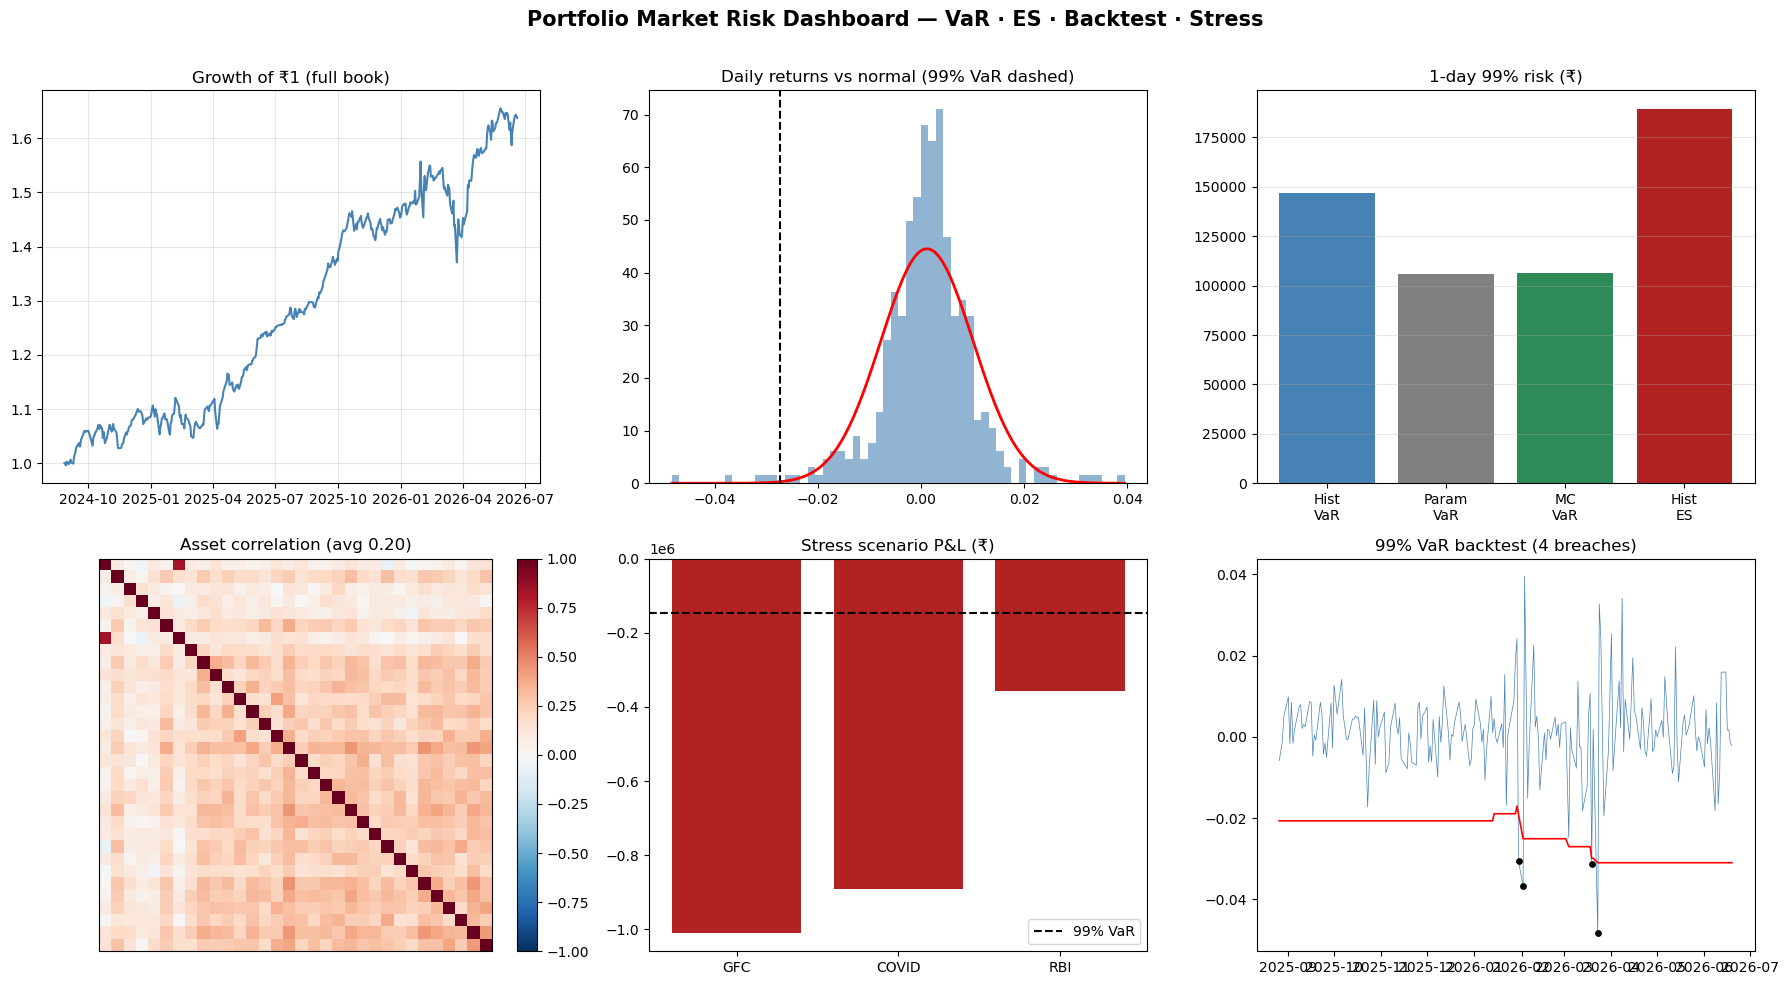

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Portfolio Market Risk Dashboard — VaR · ES · Backtest · Stress",
             fontsize=15, weight="bold")

# Panel 1 — equity curve
equity = (1 + port_full).cumprod()
ax[0,0].plot(equity.index, equity.values, color="steelblue")
ax[0,0].set_title("Growth of ₹1 (full book)"); ax[0,0].grid(alpha=.3)

# Panel 2 — return distribution vs normal
ax[0,1].hist(r, bins=60, density=True, alpha=.6, color="steelblue")
xs = np.linspace(r.min(), r.max(), 200)
ax[0,1].plot(xs, norm.pdf(xs, mu, sig), "r-", lw=2)
ax[0,1].axvline(r.quantile(0.01), color="k", ls="--")
ax[0,1].set_title("Daily returns vs normal (99% VaR dashed)")

# Panel 3 — 99% risk comparison
names = ["Hist\nVaR", "Param\nVaR", "MC\nVaR", "Hist\nES"]
vals  = [S["hist99"], S["param99"], S["mc99"], S["es99"]]
ax[0,2].bar(names, vals, color=["steelblue","gray","seagreen","firebrick"])
ax[0,2].set_title("1-day 99% risk (₹)"); ax[0,2].grid(axis="y", alpha=.3)

# Panel 4 — correlation heatmap
corr = rs_full.corr()
avg = corr.values[np.triu_indices(len(corr), k=1)].mean()
im = ax[1,0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax[1,0].set_title("Asset correlation (avg {:.2f})".format(avg))
ax[1,0].set_xticks([]); ax[1,0].set_yticks([])
fig.colorbar(im, ax=ax[1,0], fraction=.046)

# Panel 5 — stress scenarios
snames = list(stress.keys())
svals  = [stress[k] for k in snames]
ax[1,1].bar(snames, svals, color="firebrick")
ax[1,1].axhline(-S["hist99"], color="k", ls="--", label="99% VaR")
ax[1,1].set_title("Stress scenario P&L (₹)"); ax[1,1].legend()

# Panel 6 — backtest
v99 = r.rolling(250).quantile(0.01)
bt = pd.DataFrame({"r": r, "v": v99}).dropna()
breaches = bt[bt.r < bt.v]
ax[1,2].plot(bt.index, bt.r, lw=.5, color="steelblue")
ax[1,2].plot(bt.index, bt.v, color="red", lw=1.2)
ax[1,2].scatter(breaches.index, breaches.r, color="black", s=15, zorder=5)
ax[1,2].set_title("99% VaR backtest ({} breaches)".format(len(breaches)))

plt.tight_layout(rect=[0, 0, 1, 0.97])
os.makedirs(r"D:\Claude\market-risk-dashboard\output", exist_ok=True)
plt.savefig(r"D:\Claude\market-risk-dashboard\output\risk_dashboard.png",
            dpi=120, bbox_inches="tight")
plt.show()